## Linear Regression

Linear Regression is a statistical method used to model the relationship between a dependent variable and one or more independent variables. The goal of linear regression is to find the best-fitting line (or hyperplane in higher dimensions) that minimizes the sum of squared differences between the observed values and the predicted values.

The Best-Fitting Line is: 

$$Y = A + BX$$

Where:
- $Y$ is the dependent variable (the variable we are trying to predict).
- $X$ is the independent variable (the variable we are using to make predictions).
- $A$ is the intercept (the value of $Y$ when $X$ is zero).
- $B$ is the slope (the change in $Y$ for a one-unit change in $X$).

Formula for calculating the slope (B) and intercept (A) in simple linear regression:

$$B = \frac{n\sum{XY} - \sum{X}\sum{Y}}{n\sum{X^2} - (\sum{X})^2}; \quad A = \frac{\sum{Y} - B\sum{X}}{n}$$

Where:
- $n$ is the number of data points.
- $\sum{XY}$ is the sum of the product of $X$ and $Y$.
- $\sum{X}$ is the sum of the independent variable values.
- $\sum{Y}$ is the sum of the dependent variable values.

<Axes: xlabel='Height (X)', ylabel='Weight (Y)'>

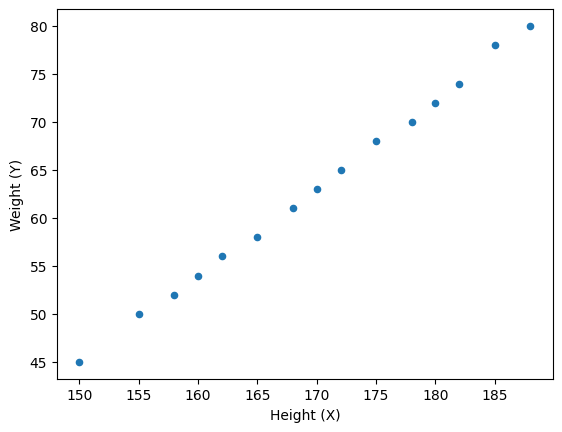

In [1]:
import pandas as pd
 
data = {
    "Height (X)": [150, 155, 158, 160, 162, 165, 168, 170, 172, 175, 178, 180, 182, 185, 188],
    "Weight (Y)": [45, 50, 52, 54, 56, 58, 61, 63, 65, 68, 70, 72, 74, 78, 80]
}

# Plot
df = pd.DataFrame(data)
# Linear Regression line
df.plot(kind='scatter', x='Height (X)', y='Weight (Y)')

Handful calculations:

In [2]:
n = len(df)
print("Number of samples:", n)

Number of samples: 15


In [3]:
df['XY'] = df['Height (X)'] * df['Weight (Y)']
print(df)
sum_xy = sum(df['XY'])
print("\nSum of XY:", sum_xy)

    Height (X)  Weight (Y)     XY
0          150          45   6750
1          155          50   7750
2          158          52   8216
3          160          54   8640
4          162          56   9072
5          165          58   9570
6          168          61  10248
7          170          63  10710
8          172          65  11180
9          175          68  11900
10         178          70  12460
11         180          72  12960
12         182          74  13468
13         185          78  14430
14         188          80  15040

Sum of XY: 162394


In [4]:
sum_x = sum(df['Height (X)'])
mean_x = sum_x / n
print("Sum of X:", sum_x)
print("Mean of X:", mean_x)

Sum of X: 2548
Mean of X: 169.86666666666667


In [5]:
sum_y = sum(df['Weight (Y)'])
mean_y = sum_y / n
print("Sum of Y:", sum_y)
print("Mean of Y:", mean_y)

Sum of Y: 946
Mean of Y: 63.06666666666667


In [6]:
squared_sum_x = sum(df['Height (X)']**2)
print("Squared sum of X:", squared_sum_x)

Squared sum of X: 434668


In [7]:
squared_sum_y = sum(df['Weight (Y)']**2)
print("Squared sum of Y:", squared_sum_y)

Squared sum of Y: 61228


In [8]:
sum_squared_x = sum_x**2
print("Sum of squared X:", sum_squared_x)

Sum of squared X: 6492304


In [9]:
# Find the best fitting line
B = (n * sum_xy - sum_x * sum_y) / (n * squared_sum_x - sum_squared_x)
A = (sum_y - B * sum_x) / n
print(f"The intercept A: {A}")
print(f"The slope B: {B}")
print(f"The best-fitting line: Y = {A} + {B}X")

The intercept A: -93.23076923076924
The slope B: 0.9201183431952663
The best-fitting line: Y = -93.23076923076924 + 0.9201183431952663X


In [10]:
df['Predicted_Weight (Y_pred)'] = A + B * df['Height (X)']
df['Actual_Weight (Y)'] = df['Weight (Y)']
print(df[['Height (X)', 'Predicted_Weight (Y_pred)', 'Actual_Weight (Y)']])

    Height (X)  Predicted_Weight (Y_pred)  Actual_Weight (Y)
0          150                  44.786982                 45
1          155                  49.387574                 50
2          158                  52.147929                 52
3          160                  53.988166                 54
4          162                  55.828402                 56
5          165                  58.588757                 58
6          168                  61.349112                 61
7          170                  63.189349                 63
8          172                  65.029586                 65
9          175                  67.789941                 68
10         178                  70.550296                 70
11         180                  72.390533                 72
12         182                  74.230769                 74
13         185                  76.991124                 78
14         188                  79.751479                 80


In [11]:
squared_errors = (df['Predicted_Weight (Y_pred)'] - df['Actual_Weight (Y)']) ** 2
print("Sum of Squared Error (SSE):", sum(squared_errors))
print("Mean Squared Error (MSE):", sum(squared_errors) / n)

Sum of Squared Error (SSE): 2.6094674556213233
Mean Squared Error (MSE): 0.17396449704142156


Text(0.5, 1.0, 'Linear Regression')

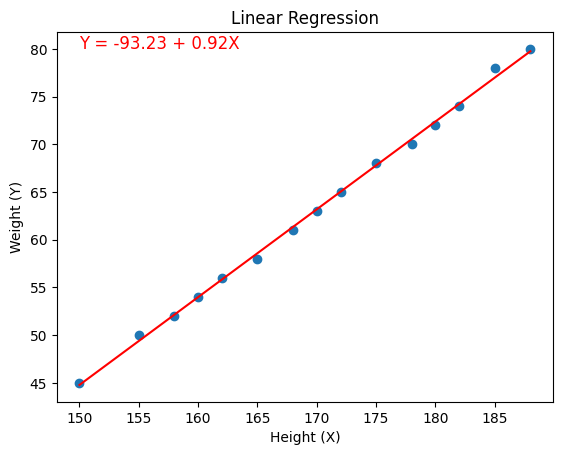

In [12]:
import matplotlib.pyplot as plt

# Draw the regression line
plt.scatter(df['Height (X)'], df['Weight (Y)'], label='Actual Data')
plt.plot(df['Height (X)'], df['Predicted_Weight (Y_pred)'], color='red', label='Regression Line')
plt.text(x=df['Height (X)'].min(), y=df['Weight (Y)'].max(), 
         s=f'Y = {A:.2f} + {B:.2f}X', fontsize=12, color='red')
plt.xlabel('Height (X)')
plt.ylabel('Weight (Y)')
plt.title('Linear Regression')

Multiple Linear Regression extends the concept of simple linear regression to include multiple independent variables. The formula for multiple linear regression is:

$$Y = A + B_1X_1 + B_2X_2 + ... + B_kX_k$$

Where:
- $Y$ is the dependent variable.
- $X_1, X_2, ..., X_k$ are the independent variables.
- $A$ is the intercept.
- $B_1, B_2, ..., B_k$ are the coefficients for each independent variable, representing the change in $Y$ for a one-unit change in the corresponding $X$ while holding other variables constant.

In [13]:
import pandas as pd
 
data = {
    'Height (cm)': [150, 155, 158, 160, 162, 165, 168, 170, 172, 175, 178, 180, 182, 185, 188],
    'Weight (kg)': [45, 50, 52, 54, 56, 58, 61, 63, 65, 68, 70, 72, 74, 78, 80],
    'Resting Heart Rate (BPM)': [68, 81, 76, 72, 69, 82, 68, 80, 84, 72, 72, 82, 65, 69, 64],
    'Daily Calories (Est.)': [1393, 1654, 1617, 1681, 1816, 1664, 1779, 1959, 1978, 2207, 2149, 2162, 2514, 2473, 2566]
}


df = pd.DataFrame(data)
# Convert to numpy
X = df[['Height (cm)', 'Weight (kg)', 'Resting Heart Rate (BPM)']].to_numpy()
Y = df['Daily Calories (Est.)'].to_numpy()

In [14]:
import numpy as np

# Add a bias term -> To learn the intercept
ones = np.ones((X.shape[0], 1))
X = np.hstack((ones, X))

Formulas for multiple linear regression coefficients can be calculated using matrix operations:

$$B = (X^TX)^{-1}X^TY$$

Where:
- $X$ is the matrix of independent variables (including a column of ones for the intercept).
- $Y$ is the vector of dependent variable values.   


In [15]:
B = np.linalg.inv(X.T @ X) @ X.T @ Y
# Interpret the result
A = B[0]
B1, B2, B3 = B[1], B[2], B[3]
# The best fitting equation
print(f"Best Equation: ({A}) + ({B1})X1 + ({B2})X2 + ({B3})X3")

Best Equation: (8506.875514674597) + (-81.11140796730456)X1 + (120.31057928013297)X2 + (-4.649522842503245)X3


In [16]:
# Make prediction
df['Daily Calories (Est.) Actual'] = df['Daily Calories (Est.)']
df['Daily Calories (Est.) Predicted'] = A + B1 * df['Height (cm)'] + B2 * df['Weight (kg)'] + B3 * df['Resting Heart Rate (BPM)']
print(df[['Daily Calories (Est.) Actual', 'Daily Calories (Est.) Predicted']])
print("\nMean Squared Error:", np.mean((df['Daily Calories (Est.) Actual'] - df['Daily Calories (Est.) Predicted'])**2))

    Daily Calories (Est.) Actual  Daily Calories (Est.) Predicted
0                           1393                      1437.972834
1                           1654                      1573.524894
2                           1617                      1594.059442
3                           1681                      1691.055876
4                           1816                      1783.402788
5                           1664                      1720.245925
6                           1779                      1902.936759
7                           1959                      1925.540827
8                           1978                      1985.341079
9                           2207                      2158.732867
10                          2149                      2156.019801
11                          2162                      2187.922916
12                          2514                      2345.363147
13                          2473                      2564.673148
14        